In [1]:
import sys
sys.path.append(r"C:\Projects\anomaly-detection\Modeling\Code")

In [2]:
import numpy as np, pandas as pd
from sklearn.metrics import average_precision_score
from eval_protocol import (prf, point_adjust, best_f1_threshold,
                           best_f1_prcurve, plot_pr_curve, time_split_per_kpi)

In [3]:
train = pd.read_csv(r"C:\Projects\anomaly-detection\Data\train.csv")
train.columns = ["timestamp", "value", "label", "kpi"]
train = time_split_per_kpi(train)

In [4]:
train

,timestamp,value,label,kpi,split
0,1493568000,1.901639,0,02e99bd4f6cfb33f,train
1,1493568060,1.786885,0,02e99bd4f6cfb33f,train
2,1493568120,2.000000,0,02e99bd4f6cfb33f,train
3,1493568180,1.885246,0,02e99bd4f6cfb33f,train
4,1493568240,1.819672,0,02e99bd4f6cfb33f,train
...,...,...,...,...,...
1240118,1500146040,3070.000000,0,e0770391decc44ce,test
1240119,1500146100,3019.000000,0,e0770391decc44ce,test
1240120,1500146160,3508.000000,0,e0770391decc44ce,test
1240121,1500146220,3341.000000,0,e0770391decc44ce,test


In [5]:
def rolling_zscore(x, window, robust=False, eps=1e-9):
    """Score = |x_t - center| / scale; center/scale tính trên [t-w, t-1].
    shift(1) đảm bảo KHÔNG dùng x_t (tránh leakage + self-masking, §1.2)."""
    s = pd.Series(np.asarray(x, float)); past = s.shift(1)
    if robust:                                   # MAD-based (§1.3) — chậm hơn
        center = past.rolling(window).median()
        mad = past.rolling(window).apply(lambda a: np.median(np.abs(a-np.median(a))), raw=True)
        scale = mad * 1.4826
    else:                                        # mean/std — nhanh, vectorized
        center = past.rolling(window).mean(); scale = past.rolling(window).std()
    scale = scale.replace(0, np.nan).fillna(eps).clip(lower=eps)
    return ((s - center).abs() / scale).fillna(0.0).values   # warmup ->

In [6]:
def run_kpi_zscore(g, windows=(15,30,60,120), robust=False):
    g = g.sort_values("timestamp")
    y = g.label.values.astype(int); x = g.value.values.astype(float); sp = g.split.values
    mv, mt = sp=="val", sp=="test"
    if y[mv].sum()==0 or y[mt].sum()==0:          # không đủ nhãn để tune/đánh giá
        return None
    best_w, best_ap, sc = None, -1, None          # tune window theo AP trên val
    for w in windows:
        s = rolling_zscore(x, w, robust=robust)
        ap = average_precision_score(y[mv], s[mv])
        if ap > best_ap: best_ap, best_w, sc = ap, w, s
    res = dict(window=best_w, ap_val=round(best_ap,3),
               ap_test=round(average_precision_score(y[mt], sc[mt]),3),
               n_anom_test=int(y[mt].sum()),
               y_test=y[mt], s_test=sc[mt])         # giữ lại để gộp vẽ PR curve
    # PW: best-F1 chính xác trên PR curve (sklearn) | PA: grid sweep + point_adjust
    thr_pw = best_f1_prcurve(y[mv], sc[mv])["threshold"]
    res["PW"] = prf(y[mt], (sc[mt] >= thr_pw).astype(int))
    thr_pa = best_f1_threshold(y[mv], sc[mv], adjust=True)["threshold"]
    res["PA"] = prf(y[mt], point_adjust(y[mt], (sc[mt] >= thr_pa).astype(int)))
    return res

In [7]:
rows=[]; agg={"PW":dict(tp=0,fp=0,fn=0),"PA":dict(tp=0,fp=0,fn=0)}; skipped=[]
pk = []                                           # list (y_test, s_test) theo từng KPI -> vẽ macro PR
for kpi,g in train.groupby("kpi"):
    r = run_kpi_zscore(g, robust=False)
    if r is None: skipped.append(kpi[:8]); continue
    pk.append((r["y_test"], r["s_test"]))
    for mode in ("PW","PA"):
        for k in ("tp","fp","fn"): agg[mode][k]+=r[mode][k]
    rows.append(dict(kpi=kpi[:8], window=r["window"], ap_test=r["ap_test"],
                     f1_pw=round(r["PW"]["fbeta"],3), f1_pa=round(r["PA"]["fbeta"],3),
                     n_anom_test=r["n_anom_test"]))

res_df = pd.DataFrame(rows).sort_values("ap_test", ascending=False)
macro_ap = res_df["ap_test"].mean()              # AP chính thức = trung bình per-KPI (khớp tune per-KPI)

def micro(d):
    p=d["tp"]/(d["tp"]+d["fp"]) if d["tp"]+d["fp"] else 0
    r=d["tp"]/(d["tp"]+d["fn"]) if d["tp"]+d["fn"] else 0
    return p, r, (2*p*r/(p+r) if p+r else 0)

display(res_df)
print("Skipped (val/test thiếu anomaly):", skipped)
print(f"MACRO AP (trung bình per-KPI) = {macro_ap:.3f}   <-- số chính thức")
for m in ("PW","PA"):
    p,r,f = micro(agg[m]); print(f"MICRO {m}: P={p:.3f} R={r:.3f} F1={f:.3f}")

,kpi,window,ap_test,f1_pw,f1_pa,n_anom_test
7,7c189dd3,60,0.435,0.511,0.421,63
12,a40b1df8,30,0.424,0.504,0.438,86
13,affb01ca,60,0.409,0.466,0.443,76
9,8bef9af9,120,0.392,0.490,0.488,73
5,40e25005,60,0.184,0.284,0.542,112
6,71595dd7,60,0.125,0.167,0.702,228
15,cff6d3c0,60,0.120,0.164,0.718,276
4,1c35dbf5,120,0.113,0.190,0.010,2709
17,e0770391,120,0.084,0.032,0.955,2706
16,da403e4e,15,0.084,0.018,0.764,238


Skipped (val/test thiếu anomaly): ['046ec29d', '54e8a140', '769894ba', '76f4550c', '8a20c229', '9bd90500', 'a5bf5d65', 'b3b2e6d1']
MACRO AP (trung bình per-KPI) = 0.153   <-- số chính thức
MICRO PW: P=0.041 R=0.378 F1=0.074
MICRO PA: P=0.726 R=0.753 F1=0.740


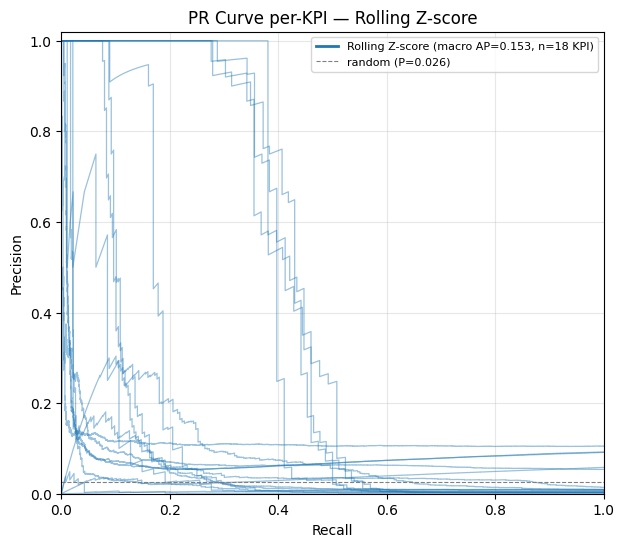

In [8]:
# PR curve per-KPI (macro) — số chính thức, khớp với việc tune threshold riêng từng KPI
# mỗi đường mờ = 1 KPI; legend ghi macro AP = trung bình AP per-KPI
plot_pr_curve({"Rolling Z-score": pk}, per_kpi=True,
              title="PR Curve per-KPI — Rolling Z-score");